In [1]:
%pip list |grep llama

llama-index                       0.9.48
Note: you may need to restart the kernel to use updated packages.


In [1]:
import openai, os
from openai import OpenAI
from llama_index import GPTVectorStoreIndex, SimpleDirectoryReader

openai.api_key = os.environ.get("OPENAI_API_KEY")
client = OpenAI(api_key=openai.api_key)

documents = SimpleDirectoryReader('./data/mr_fujino').load_data()
index = GPTVectorStoreIndex.from_documents(documents)
print(index)
index.storage_context.persist(persist_dir="index_mr_fujino.json")

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-h8hvV***************************************4bF7. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [2]:
query_engine = index.as_query_engine()
response = query_engine.query("鲁迅先生在日本学习医学的老师是谁？")
print(response)

鲁迅先生在日本学习医学的老师是藤野先生。


In [4]:
response = query_engine.query("鲁迅先生去哪里学的医学？")
print(response)

鲁迅先生去仙台学医学。


In [5]:
# https://docs.llamaindex.ai/en/stable/module_guides/models/prompts/usage_pattern.html
from llama_index import PromptTemplate

query_str = "鲁迅先生去哪里学的医学？"
DEFAULT_TEXT_QA_PROMPT_TMPL = (
    "Context information is below. \n"
    "---------------------\n"
    "{context_str}"
    "\n---------------------\n"
    "Given the context information and not prior knowledge, "
    "answer the question: {query_str}\n"
)
QA_PROMPT = PromptTemplate(DEFAULT_TEXT_QA_PROMPT_TMPL)
retriever_query_engine = index.as_query_engine(text_qa_template=QA_PROMPT)
response = retriever_query_engine.query(query_str)
print(response)


鲁迅先生去仙台学医学。


In [6]:
QA_PROMPT_TMPL = (
    "下面的“我”指的是鲁迅先生 \n"
    "---------------------\n"
    "{context_str}"
    "\n---------------------\n"
    "根据这些信息，请回答问题: {query_str}\n"
    "如果您不知道的话，请回答不知道\n"
)
QA_PROMPT = PromptTemplate(QA_PROMPT_TMPL)
retriever_query_engine = index.as_query_engine(text_qa_template=QA_PROMPT)
response = retriever_query_engine.query("请问林黛玉和贾宝玉是什么关系？")
print(response)

不知道


In [7]:
from langchain.text_splitter import SpacyTextSplitter
from llama_index import GPTListIndex, ServiceContext, VectorStoreIndex
from llama_index.llms.openai import OpenAI
from llama_index.node_parser import SimpleNodeParser, SentenceSplitter

# define LLM
llm = OpenAI(temperature=0, model="gpt-3.5-turbo", max_tokens=1024)

# text_splitter = SpacyTextSplitter(pipeline="zh_core_web_sm", chunk_size = 2048)
# parser = SimpleNodeParser(text_splitter=text_splitter)
parser = SimpleNodeParser.from_defaults()


documents = SimpleDirectoryReader('./data/mr_fujino').load_data()

nodes = parser.get_nodes_from_documents(documents)
service_context = ServiceContext.from_defaults(llm=llm)
list_index = GPTListIndex(nodes=nodes, service_context=service_context)

In [8]:
query_engine = list_index.as_query_engine(response_mode="tree_summarize")
response = query_engine.query("下面鲁迅先生以第一人称‘我’写的内容，请你用中文总结一下:")
print(response)

鲁迅先生以第一人称描述了在日本学医的经历，包括学习解剖学的过程、教授的指导、讲义的修改、与教授的互动，以及对中国文化的误解和困惑。他最终受到藤野先生的影响，选择离开医学学习，转向学习生物学，但仍怀念藤野先生的教诲和鼓励。


In [9]:
# Use HierarchicalNodeParser
from langchain.text_splitter import SpacyTextSplitter
from llama_index import GPTListIndex, ServiceContext
from llama_index.llms.openai import OpenAI
from llama_index.node_parser import HierarchicalNodeParser

# define LLM
llm = OpenAI(temperature=0, model="gpt-3.5-turbo", max_tokens=1024)

# text_splitter = SpacyTextSplitter(pipeline="zh_core_web_sm", chunk_size = 2048)

parser = HierarchicalNodeParser.from_defaults()

documents = SimpleDirectoryReader('./data/mr_fujino').load_data()
nodes = parser.get_nodes_from_documents(documents)
service_context = ServiceContext.from_defaults(llm=llm)
list_index = GPTListIndex(nodes=nodes, service_context=service_context)


In [10]:
query_engine = list_index.as_query_engine(response_mode="tree_summarize")
response = query_engine.query("下面鲁迅先生以第一人称‘我’写的内容，请你用中文总结一下:")
print(response)

这段内容描述了主人公在医学学习过程中遇到的一位老师藤野先生的教诲和影响。在学习解剖学等课程时，主人公受到藤野先生的悉心指导和帮助，尽管有时表现得不够用功和任性。即使选择离开医学领域，但对藤野先生的感激和尊重仍然深刻，将其视为永久的纪念。


In [15]:
%pip install torch transformers sentencepiece Pillow

  Using cached torch-2.2.1-cp311-none-macosx_10_9_x86_64.whl.metadata (25 kB)
  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
  Using cached sentencepiece-0.2.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata (7.7 kB)
  Using cached huggingface_hub-0.21.4-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.15.2-cp311-cp311-macosx_10_12_x86_64.whl.metadata (6.7 kB)
  Using cached safetensors-0.4.2-cp311-cp311-macosx_10_12_x86_64.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 3.0 MB/s eta 0:00:0000:0100:02
Using cached transformers-4.38.2-py3-none-any.whl (8.5 MB)
Using cached sentencepiece-0.2.0-cp311-cp311-macosx_10_9_x86_64.whl (1.2 MB)
Using cached huggingface_hub-0.21.4-py3-none-any.whl (346 kB)
Using cached safetensors-0.4.2-cp311-cp311-macosx_10_12_x86_64.whl (426 kB)
Using cached tokenizers-0.15.2-cp311-cp311-macosx_10_12_x86_64.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
from llama_index.readers.file.base import ImageReader
from llama_index import SimpleDirectoryReader, VectorStoreIndex
from llama_index.readers.file.base import (
    DEFAULT_FILE_READER_CLS, 
    ImageReader,
)
from llama_index.response.notebook_utils import (
    display_response, 
    display_image,
)
from llama_index.indices.query.query_transform.base import (
    ImageOutputQueryTransform,
)

# NOTE: we add filename as metadata for all documents
filename_fn = lambda filename: {'file_name': filename}

receipt_reader = SimpleDirectoryReader(
    input_dir='./data/receipts', 
    file_metadata=filename_fn,
)
receipt_documents = receipt_reader.load_data()

# receipts_index = GPTVectorStoreIndex.from_documents(receipt_documents)

In [2]:
# receipts_index = GPTVectorStoreIndex.from_documents(receipt_documents)
receipts_index = VectorStoreIndex.from_documents(receipt_documents)
# receipts_response = receipts_index.query(
    'When was the last time I went to McDonald\'s and how much did I spend. \
    Also show me the receipt from my visit.',
#     query_transform=ImageOutputQueryTransform(width=400)
# )
# display_response(receipts_response)
# receipts_index = VectorStoreIndex.from_documents(receipt_documents)

ValueError: Cannot build index from nodes with no content. Please ensure all nodes have content.

In [4]:
%pip install qdrant_client

  Using cached grpcio-1.62.0-cp311-cp311-macosx_10_10_universal2.whl.metadata (4.0 kB)
  Using cached protobuf-4.25.3-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 181.9 kB/s eta 0:00:00a 0:00:01
Using cached grpcio-1.62.0-cp311-cp311-macosx_10_10_universal2.whl (10.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 1.1 MB/s eta 0:00:0000:0100:010m
Using cached protobuf-4.25.3-cp37-abi3-macosx_10_9_universal2.whl (394 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install torch
%pip install git+https://github.com/openai/CLIP.git

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/r6/m94pzwms76lc737dhxsx_7wc0000gn/T/pip-req-build-dg05z3pd
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/r6/m94pzwms76lc737dhxsx_7wc0000gn/T/pip-req-build-dg05z3pd
  Resolved https://github.com/openai/CLIP.git to commit a1d071733d7111c9c014f024669f959182114e33
  Preparing metadata (setup.py) ... done
  Using cached wcwidth-0.2.13-py2.py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.4/53.4 kB 205.2 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 407.9 kB/s eta 0:00:00a 0:00:01
Using cached wcwidth-0.2.13-py2.py3-none-any.whl (34 kB)
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369497 sha256=386aef1b7daeb248a97091515f777e499bc4465862683caf6f1702359fc73a3b
  Stored in directory: /private/var/folders/r6/m94p

In [13]:
%pip install ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 26.0 kB/s eta 0:00:00a 0:00:01
  Attempting uninstall: httpx
    Found existing installation: httpx 0.27.0
    Uninstalling httpx-0.27.0:
      Successfully uninstalled httpx-0.27.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from llama_index.indices.multi_modal.base import MultiModalVectorStoreIndex
from llama_index.vector_stores import QdrantVectorStore
from llama_index import SimpleDirectoryReader, StorageContext
from llama_index.embeddings import ClipEmbedding

import qdrant_client
from llama_index import (
    SimpleDirectoryReader,
)

# Create a local Qdrant vector store
client = qdrant_client.QdrantClient(path="qdrant_mm_db_peter2")

text_store = QdrantVectorStore(
    client=client, collection_name="text_collection"
)
image_store = QdrantVectorStore(
    client=client, collection_name="image_collection"
)
storage_context = StorageContext.from_defaults(
    vector_store=text_store, image_store=image_store
)

image_embed_model = ClipEmbedding()

# Create the MultiModal index
documents = SimpleDirectoryReader("./data/receipts").load_data()
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    image_embed_model=image_embed_model,
)

In [3]:
from llama_index.multi_modal_llms import OllamaMultiModal
mm_model = OllamaMultiModal(model="llava:13b")

Initialize OpenAIMultiModal and Load Images from URLs

In [4]:
# https://github.com/run-llama/llama_index/blob/v0.9.48/docs/examples/multi_modal/openai_multi_modal.ipynb
from llama_index.multi_modal_llms.openai import OpenAIMultiModal

from llama_index.multi_modal_llms.generic_utils import (
    load_image_urls,
)

image_urls = [
    # "https://www.visualcapitalist.com/wp-content/uploads/2023/10/US_Mortgage_Rate_Surge-Sept-11-1.jpg",
    # "https://www.sportsnet.ca/wp-content/uploads/2023/11/CP1688996471-1040x572.jpg",
    "https://res.cloudinary.com/hello-tickets/image/upload/c_limit,f_auto,q_auto,w_1920/v1640835927/o3pfl41q7m5bj8jardk0.jpg",
    # "https://www.cleverfiles.com/howto/wp-content/uploads/2018/03/minion.jpg",
]

image_documents = load_image_urls(image_urls)

openai_mm_llm = OpenAIMultiModal(
    model="gpt-4-vision-preview", api_key=openai.api_key, max_new_tokens=300
)

https://res.cloudinary.com/hello-tickets/image/upload/c_limit,f_auto,q_auto,w_1920/v1640835927/o3pfl41q7m5bj8jardk0.jpg


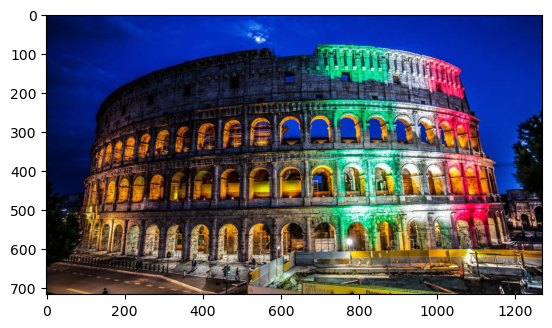

In [5]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

img_response = requests.get(image_urls[0])
print(image_urls[0])
img = Image.open(BytesIO(img_response.content))
plt.imshow(img)

Complete a prompt with a bunch of images

In [6]:
complete_response = openai_mm_llm.complete(
    prompt="Describe the images as an alternative text",
    image_documents=image_documents,
)
# Error caused by the key

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-h8hvV***************************************4bF7. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}